# 01 · Data sintetis dan rekonsiliasi neraca

> Fictional Islamic bank, fully synthetic data. Semua logika ada di `src/erm/`; notebook hanya narasi dan visual.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import pandas as pd
from erm import datastore, kri, scoring, validation

Generator dijalankan lewat `make data`. Di sini data raw dibaca lalu direkonsiliasi (spec §12 no. 1–2).

In [2]:
raw = kri.load_raw()
profile = datastore.load_config()['bank_profile']
validation.anchor_check(raw['balance_sheet_monthly'], raw['capital_monthly'], profile)

,item,spec,generated,deviation_pct,within_tolerance
0,Kas & giro BI,5000,5000.0,0.0,True
1,Penempatan pada bank lain,2000,2000.0,0.0,True
2,Portofolio sukuk,10000,10000.0,0.0,True
3,Pembiayaan bruto,41000,41000.0,0.0,True
4,Cadangan kerugian,-1000,-1000.0,0.0,True
5,Aset lain,3000,3000.0,0.0,True
6,Total aset,60000,60000.0,0.0,True
7,Giro wadiah,8000,8000.0,0.0,True
8,Tabungan,16000,16000.0,0.0,True
9,Deposito mudharabah,24000,24000.0,0.0,True


In [3]:
validation.reconciliation_table(raw, datastore.reporting_period())

,item,balance_sheet,granular,source,difference,reconciled
0,Pembiayaan bruto,41000.0,40999.999981,financing_portfolio.outstanding,-0.000019,True
1,Portofolio sukuk,10000.0,10000.000000,investment_portfolio (FVOCI MV + AC face),0.000000,True
2,Total DPK,48000.0,48000.000000,deposits_monthly.balance,0.000000,True
3,Total aset,60000.0,60000.000000,maturity_profile.assets_maturing,0.000000,True
4,Total liabilitas,53000.0,53000.000000,maturity_profile.liabilities_maturing,0.000000,True


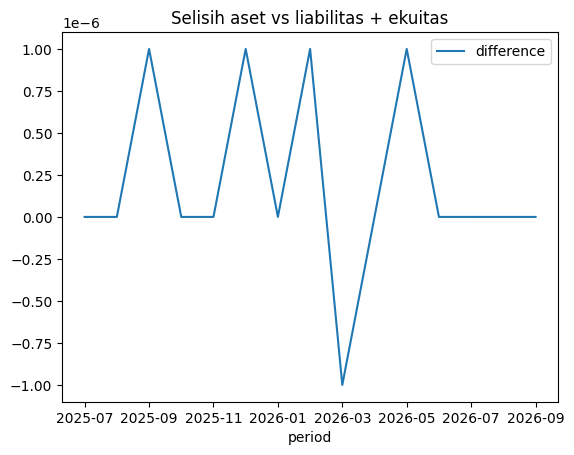

In [4]:
validation.balance_check(raw['balance_sheet_monthly']).plot(y='difference', title='Selisih aset vs liabilitas + ekuitas');